In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
df=pd.read_csv('Datasets\Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df=df.drop('User ID',axis=1)

In [8]:
df

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0
...,...,...,...,...
395,Female,46,41000,1
396,Male,51,23000,1
397,Female,50,20000,1
398,Male,36,33000,0


In [9]:
df.nunique()

Gender               2
Age                 43
EstimatedSalary    117
Purchased            2
dtype: int64

<AxesSubplot:xlabel='Age', ylabel='Density'>

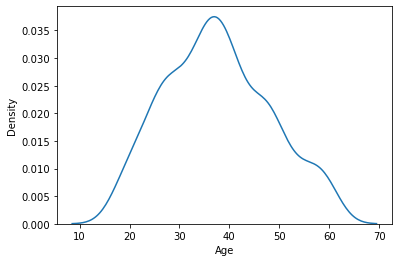

In [10]:
sns.kdeplot(df['Age'])

<AxesSubplot:xlabel='EstimatedSalary', ylabel='Density'>

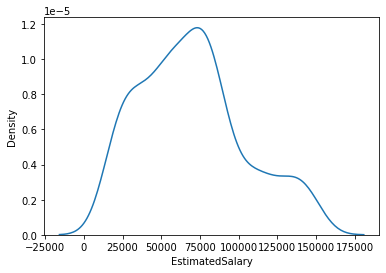

In [11]:
sns.kdeplot(df['EstimatedSalary'])

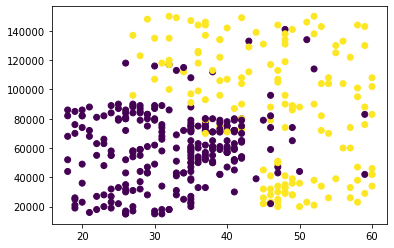

In [12]:
plt.scatter(x=df['Age'],y=df['EstimatedSalary'],c=df['Purchased'])

In [14]:
df=pd.get_dummies(df)

In [15]:
df

,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
0,19,19000,0,0,1
1,35,20000,0,0,1
2,26,43000,0,1,0
3,27,57000,0,1,0
4,19,76000,0,0,1
...,...,...,...,...,...
395,46,41000,1,1,0
396,51,23000,1,0,1
397,50,20000,1,1,0
398,36,33000,0,0,1


In [16]:
y=df['Purchased']
x=df.drop('Purchased',axis=1)

In [17]:
print(x.shape)
print(y.shape)

(400, 4)
(400,)


In [18]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=3)

In [19]:
scaler=StandardScaler()
scaler.fit(x_train)

StandardScaler()

In [20]:
x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

<AxesSubplot:ylabel='Density'>

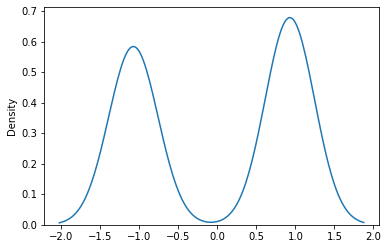

In [26]:
sns.kdeplot(x_train_scaled[:,2])

<AxesSubplot:ylabel='Density'>

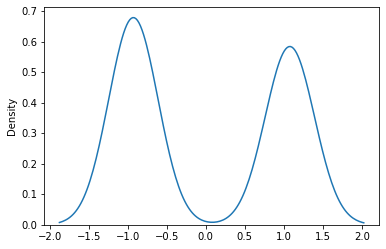

In [28]:
sns.kdeplot(x_train_scaled[:,3])

In [33]:
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [34]:
lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

LogisticRegression()

In [35]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [36]:
print(accuracy_score(y_test,y_pred))
print(accuracy_score(y_test,y_pred_scaled))

0.6875
0.8375
